# NLP Identity Uniqueness System — Full Runnable Pipeline
### Pefindo Credit Bureau — Productive Lending Underwriting

**Purpose:** Measure how many distinct identity attribute values each borrower has across all their loan applications.  
**Modules:** M1 Address · M2 Phone · M3a KTP · M3b NPWP  
**Data format:** EAV — each row is one `(nomor_identitas, element_category, value)` observation.

---

### Run Order (top to bottom)

| Phase | Step | Produces |
|-------|------|----------|
| 1 | Preprocessing demos | — |
| 2 | Data audit | — |
| 3 | Split 70/15/15 | `data/processed/{train,val,test}.csv` |
| 4 | Generate training pairs | `data/labeled/address_pairs_to_label.csv`, `phone_pairs_labeled.csv` |
| 5 | Generate validation pairs | `data/labeled/address_pairs_val.csv`, `phone_pairs_val.csv` |
| 6 | Train classifier | `models/address_classifier.pkl`, `models/address_tfidf.pkl` |
| 7 | Model selection | `logs/model_selection_report.json`, `config.json` updated |
| 8 | Overfitting gate | `logs/learning_curve.png` |
| 9 | **Final eval** ⚠ one-way door | `logs/final_eval_report.json`, `logs/final_eval_per_identity.csv` |
| 10 | Regression tests | 127/127 must pass |

In [40]:
import os, sys, json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import mlflow
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# Ensure we run from project root so all relative paths resolve
PROJECT_ROOT = os.getcwd()
if 'NLP Uniqueness System' not in PROJECT_ROOT:
    raise RuntimeError('Run this notebook from the project root directory.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# MLflow logs to ./mlruns — no server needed
mlflow.set_tracking_uri('file:./mlruns')

with open('config.json') as f:
    CONFIG = json.load(f)

print('Working directory:', PROJECT_ROOT)
print('Config keys:', list(CONFIG.keys()))

Working directory: /Users/almira.izzaty/Documents/Claude Analysis/NLP Uniqueness System
Config keys: ['address', 'phone', 'ktp', 'npwp', 'element_category_map', 'selected_address_method', 'selected_phone_prefix']


---
## Phase 1 — Preprocessing

Three normalization functions clean raw Pefindo EAV values before any clustering:
- `normalize_address` — strips `ALAMAT.` prefix, expands Indonesian abbreviations (Jl.→Jalan, Kec.→Kecamatan), lowercases
- `normalize_phone` — strips `+62` / `62` / leading `0` → returns `8XXXXXXXXX`; returns `None` for junk
- `normalize_id_number` — strips non-digits, validates length (KTP=16, NPWP=15); all-zero → `None`

In [7]:
from src.preprocessing import normalize_address, normalize_phone, normalize_id_number

print('=== normalize_address ===')
for raw in [
    'ALAMAT. Jl. Sudirman No.5 Kec. Menteng Jakarta Pusat',
    'jalan sudirman no 5 kecamatan menteng jakarta pusat',
    'ALAMAT.Jl Merdeka RT 001/002 Kel Gambir',
    None,
]:
    print(f'  IN : {str(raw)[:65]}')
    print(f'  OUT: {normalize_address(raw)}')
    print()

print('=== normalize_phone ===')
for p in ['+62 812-3456-7890', '628123456789', '0812 3456 7890', '812-3456-7890', '00000000000', '1234']:
    print(f'  {str(p):25s}  →  {normalize_phone(p)}')

print('\n=== normalize_id_number ===')
print(f'  KTP  : {normalize_id_number("3171012345678901", 16)}')
print(f'  NPWP : {normalize_id_number("12.345.678.9-012.000", 15)}')
print(f'  None : {normalize_id_number(None, 16)}')
print(f'  Zeros: {normalize_id_number("0000000000000000", 16)}')

=== normalize_address ===
  IN : ALAMAT. Jl. Sudirman No.5 Kec. Menteng Jakarta Pusat
  OUT: jalan sudirman nomor5 kecamatan menteng jakarta pusat

  IN : jalan sudirman no 5 kecamatan menteng jakarta pusat
  OUT: jalan sudirman nomor 5 kecamatan menteng jakarta pusat

  IN : ALAMAT.Jl Merdeka RT 001/002 Kel Gambir
  OUT: jalan merdeka rt 1 002 kelurahan gambir

  IN : None
  OUT: None

=== normalize_phone ===
  +62 812-3456-7890          →  81234567890
  628123456789               →  8123456789
  0812 3456 7890             →  81234567890
  812-3456-7890              →  81234567890
  00000000000                →  None
  1234                       →  None

=== normalize_id_number ===
  KTP  : 3171012345678901
  NPWP : 123456789012000
  None : None
  Zeros: None


---
## Phase 2 — Data Audit

Load the raw EAV dataset and check coverage per module before any splitting.

In [8]:
raw = pd.read_csv('data/raw/applications.csv', dtype=str)
n_ids = raw['nomor_identitas'].nunique()

print(f'Raw data  : {len(raw):,} rows  |  {n_ids:,} unique identities')
print(f'Columns   : {list(raw.columns)}')
print(f'\nelement_category value counts:')
print(raw['element_category'].value_counts().to_string())

Raw data  : 265,155 rows  |  8,989 unique identities
Columns   : ['value', 'id_elemen', 'id_pelapor', 'tahun_bulan_data', 'username', 'nomor_identitas', 'id_report', 'tgl_permintaan', 'npwp', 'email', 'telepon', 'batch_name', 'element_category']

element_category value counts:
element_category
Alamat                    75609
Tempat Bekerja            47596
Nomor Telepon             35657
Nomor Telepon Seluler     30764
Nama Gadis Ibu Kandung    17895
Nama Debitur              13057
NPWP                      12708
Email                     11755
Nomor Identitas           10207
Tanggal Lahir              9907


In [9]:
MODULE_CATS = {
    'Alamat'               : 'M1 — Address',
    'Nomor Telepon Seluler': 'M2 — Phone',
    'Nomor Identitas'      : 'M3a — KTP',
    'NPWP'                 : 'M3b — NPWP',
}

print(f'{"Module":<22}  {"IDs w/ data":>12}  {"Coverage":>10}  {"Multi-record %":>15}')
print('-' * 65)
for cat, label in MODULE_CATS.items():
    sub = raw[raw['element_category'] == cat]
    ids_with = sub['nomor_identitas'].nunique()
    multi    = (sub.groupby('nomor_identitas').size() > 1).mean() * 100
    print(f'{label:<22}  {ids_with:>12,}  {ids_with/n_ids*100:>9.1f}%  {multi:>14.1f}%')

# Address record count distribution
addr_cnt = raw[raw['element_category'] == 'Alamat'].groupby('nomor_identitas').size()
print(f'\nAddress records per identity (percentiles):')
print(addr_cnt.describe(percentiles=[.5,.75,.9,.99]).round(1).to_string())

Module                   IDs w/ data    Coverage   Multi-record %
-----------------------------------------------------------------
M1 — Address                   8,981       99.9%            90.0%
M2 — Phone                     8,532       94.9%            81.3%
M3a — KTP                      8,717       97.0%            12.4%
M3b — NPWP                     5,663       63.0%            64.4%

Address records per identity (percentiles):
count    8981.0
mean        8.4
std         7.3
min         1.0
50%         6.0
75%        11.0
90%        18.0
99%        35.0
max        65.0


---
## Phase 3 — Data Split (70 / 15 / 15)

Split at **identity level** — no identity appears in more than one split.  
Stratified by address count bins so each split has a representative mix of borrower complexity.

> **Note:** Running this cell overwrites existing split files. With `seed=42` the output is deterministic.

In [41]:
from src.split import create_splits

train, val, test = create_splits(raw, seed=42)

Train : 6292 identities  (184943 rows)
Val   : 1348 identities  (40240 rows)
Test  : 1349 identities  (39972 rows)
✓ No leakage confirmed. TEST SET LOCKED — do not load until Phase 6.


In [42]:
# Verify saved files and no leakage
for name, path in [('Train', 'data/processed/train.csv'),
                   ('Val',   'data/processed/val.csv'),
                   ('Test',  'data/processed/test.csv')]:
    df = pd.read_csv(path)
    print(f'{name:5s}: {df["nomor_identitas"].nunique():5,} identities  {len(df):7,} rows  →  {path}')

train_ids = set(train['nomor_identitas'])
val_ids   = set(val['nomor_identitas'])
test_ids  = set(test['nomor_identitas'])
assert not train_ids & test_ids
assert not val_ids   & test_ids
assert not train_ids & val_ids
print('\nLeakage check: ✓ PASS')
print('TEST SET IS NOW LOCKED — do not open until Phase 9.')

Train: 6,292 identities  184,943 rows  →  data/processed/train.csv
Val  : 1,348 identities   40,240 rows  →  data/processed/val.csv
Test : 1,349 identities   39,972 rows  →  data/processed/test.csv

Leakage check: ✓ PASS
TEST SET IS NOW LOCKED — do not open until Phase 9.


---
## Phase 4 — Generate Training Labeled Pairs

Auto-label address pairs with the **3-signal rule**:
- `token_set ≥ 88` → **SAME**
- `token_set < 78` → **DIFFERENT**
- Borderline (78–87): `token_sort ≥ 65` or `partial_ratio ≥ 85` → **SAME**, else **DIFFERENT**

Phone pairs labeled by `phone_1[:9] == phone_2[:9]` (first 9 digits match).

In [10]:
from rapidfuzz import fuzz

SAME_T    = CONFIG['address']['token_set_threshold']  # 88
DIFF_T    = CONFIG['address']['borderline_lower']     # 78
SORT_T    = 65
PARTIAL_T = 85

def _label_addr_pair(a1: str, a2: str):
    ts  = round(fuzz.token_set_ratio(a1, a2))
    tso = round(fuzz.token_sort_ratio(a1, a2))
    pr  = round(fuzz.partial_ratio(a1, a2))
    if ts >= SAME_T:
        label = 'SAME'
    elif ts < DIFF_T:
        label = 'DIFFERENT'
    elif tso >= SORT_T or pr >= PARTIAL_T:
        label = 'SAME'
    else:
        label = 'DIFFERENT'
    return label, ts, tso, pr

# Build pairs from ALL raw data (addresses seen in training context)
addr_df = raw[raw['element_category'] == 'Alamat'].dropna(subset=['nomor_identitas', 'value'])
pairs = []
for identity, group in addr_df.groupby('nomor_identitas'):
    raws = group['value'].tolist()
    for a1_raw, a2_raw in itertools.combinations(raws, 2):
        a1 = normalize_address(a1_raw)
        a2 = normalize_address(a2_raw)
        if not a1 or not a2:
            continue
        label, ts, tso, pr = _label_addr_pair(a1, a2)
        pairs.append({
            'address_1_raw': a1_raw, 'address_1_clean': a1,
            'address_2_raw': a2_raw, 'address_2_clean': a2,
            'token_set_score': ts, 'token_sort_score': tso, 'partial_score': pr,
            'label': label,
        })

all_pairs = pd.DataFrame(pairs)
print(f'Total pairs generated: {len(all_pairs):,}')
print(f'  SAME      : {(all_pairs["label"]=="SAME").sum():,}')
print(f'  DIFFERENT : {(all_pairs["label"]=="DIFFERENT").sum():,}')

Total pairs generated: 507,002
  SAME      : 185,144
  DIFFERENT : 321,858


In [11]:
# Sample up to 10,000 pairs (balanced: 5k SAME + 5k DIFFERENT)
same_pool = all_pairs[all_pairs['label'] == 'SAME']
diff_pool = all_pairs[all_pairs['label'] == 'DIFFERENT']
n_same = min(5000, len(same_pool))
n_diff = min(5000, len(diff_pool))

train_pairs = pd.concat([
    same_pool.sample(n_same, random_state=42),
    diff_pool.sample(n_diff, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

train_pairs.to_csv('data/labeled/address_pairs_to_label.csv', index=False)
vc = train_pairs['label'].value_counts()
print(f'Address training pairs saved: {len(train_pairs):,} rows')
print(f'  SAME      : {vc.get("SAME", 0):,}')
print(f'  DIFFERENT : {vc.get("DIFFERENT", 0):,}')
print('→ data/labeled/address_pairs_to_label.csv')

Address training pairs saved: 10,000 rows
  SAME      : 5,000
  DIFFERENT : 5,000
→ data/labeled/address_pairs_to_label.csv


In [12]:
# Phone pairs — labeled by prefix@9 match
phone_df = raw[raw['element_category'] == 'Nomor Telepon Seluler'].dropna(subset=['nomor_identitas', 'value'])
phone_pairs = []
for identity, group in phone_df.groupby('nomor_identitas'):
    phones = list(dict.fromkeys(p for p in [normalize_phone(v) for v in group['value']] if p))
    for p1, p2 in itertools.combinations(phones, 2):
        phone_pairs.append({
            'nomor_identitas': identity,
            'phone_1': p1, 'phone_2': p2,
            'label': 'SAME' if p1[:9] == p2[:9] else 'DIFFERENT',
        })

phone_pairs_df = pd.DataFrame(phone_pairs)
phone_pairs_df.to_csv('data/labeled/phone_pairs_labeled.csv', index=False)
pvc = phone_pairs_df['label'].value_counts()
print(f'Phone training pairs saved: {len(phone_pairs_df):,} rows')
print(f'  SAME      : {pvc.get("SAME", 0):,}')
print(f'  DIFFERENT : {pvc.get("DIFFERENT", 0):,}')
print('→ data/labeled/phone_pairs_labeled.csv')

Phone training pairs saved: 19,957 rows
  SAME      : 452
  DIFFERENT : 19,505
→ data/labeled/phone_pairs_labeled.csv


---
## Phase 5 — Generate Validation Pairs

Val pairs use **val.csv identities only** — zero overlap with test set.  
No sampling: all combinations from val identities are included.  
These pairs are used exclusively for model selection in Phase 7.

In [13]:
val_df = pd.read_csv('data/processed/val.csv', dtype=str)

val_addr = val_df[val_df['element_category'] == 'Alamat'].dropna(subset=['nomor_identitas', 'value'])
val_addr_pairs = []
for identity, group in val_addr.groupby('nomor_identitas'):
    raws = group['value'].tolist()
    for a1_raw, a2_raw in itertools.combinations(raws, 2):
        a1 = normalize_address(a1_raw)
        a2 = normalize_address(a2_raw)
        if not a1 or not a2:
            continue
        label, ts, tso, pr = _label_addr_pair(a1, a2)
        val_addr_pairs.append({
            'nomor_identitas': identity,
            'address_1_raw': a1_raw, 'address_1_clean': a1,
            'address_2_raw': a2_raw, 'address_2_clean': a2,
            'token_set_score': ts, 'token_sort_score': tso, 'partial_score': pr,
            'label': label,
        })

val_addr_df = pd.DataFrame(val_addr_pairs)
val_addr_df.to_csv('data/labeled/address_pairs_val.csv', index=False)
vavc = val_addr_df['label'].value_counts()
print(f'Address val pairs saved: {len(val_addr_df):,} rows')
print(f'  SAME      : {vavc.get("SAME", 0):,}')
print(f'  DIFFERENT : {vavc.get("DIFFERENT", 0):,}')
print('→ data/labeled/address_pairs_val.csv')

Address val pairs saved: 81,116 rows
  SAME      : 30,018
  DIFFERENT : 51,098
→ data/labeled/address_pairs_val.csv


In [14]:
val_phone = val_df[val_df['element_category'] == 'Nomor Telepon Seluler'].dropna(subset=['nomor_identitas', 'value'])
val_phone_pairs = []
for identity, group in val_phone.groupby('nomor_identitas'):
    phones = list(dict.fromkeys(p for p in [normalize_phone(v) for v in group['value']] if p))
    for p1, p2 in itertools.combinations(phones, 2):
        val_phone_pairs.append({
            'nomor_identitas': identity,
            'phone_1': p1, 'phone_2': p2,
            'label': 'SAME' if p1[:9] == p2[:9] else 'DIFFERENT',
        })

val_phone_df = pd.DataFrame(val_phone_pairs)
val_phone_df.to_csv('data/labeled/phone_pairs_val.csv', index=False)
vpvc = val_phone_df['label'].value_counts()
print(f'Phone val pairs saved: {len(val_phone_df):,} rows')
print(f'  SAME      : {vpvc.get("SAME", 0):,}')
print(f'  DIFFERENT : {vpvc.get("DIFFERENT", 0):,}')
print('→ data/labeled/phone_pairs_val.csv')

Phone val pairs saved: 2,915 rows
  SAME      : 74
  DIFFERENT : 2,841
→ data/labeled/phone_pairs_val.csv


---
## Phase 6 — Train Address Classifier

Fits TF-IDF on train corpus, sweeps **9 candidate classifiers** via 5-fold CV.  
Selection rule: `val_precision ≥ 0.85` AND `gap ≤ 0.10`, then highest F1.  
Saves `models/address_classifier.pkl` and `models/address_tfidf.pkl`.

> **Runtime: ~3–5 minutes** on the full dataset.

In [15]:
from src.train import train_address_classifier

clf = train_address_classifier(
    labeled_path='data/labeled/address_pairs_to_label.csv',
    train_csv='data/processed/train.csv',
)

vec = joblib.load('models/address_tfidf.pkl')
print(f'\nSelected classifier : {type(clf.named_steps["clf"]).__name__}')
print(f'TF-IDF vocabulary   : {len(vec.vocabulary_):,} terms')

Training on 10000 labeled pairs | SAME: 5000 | DIFFERENT: 5000
  ✓          LogReg_C0.01    P=0.933  R=0.981  F1=0.957  gap=-0.001
  ✓          LogReg_C0.1     P=0.961  R=0.982  F1=0.971  gap=-0.000
  ✓          LogReg_C1.0     P=0.967  R=0.977  F1=0.972  gap=-0.000
  ✓          LogReg_C10      P=0.968  R=0.976  F1=0.972  gap=0.001
  ✓          RF_50           P=0.998  R=1.000  F1=0.999  gap=0.001
  ✓          RF_200          P=0.999  R=1.000  F1=0.999  gap=0.001
  ✓          GBM             P=0.999  R=1.000  F1=1.000  gap=0.000
  ✓          SVM_RBF         P=0.972  R=0.985  F1=0.978  gap=0.002
  ✓          SVM_Linear      P=0.966  R=0.979  F1=0.972  gap=0.001

       model  val_precision  val_recall  val_f1    gap  overfit
         GBM          0.999       1.000   1.000  0.000    False
      RF_200          0.999       1.000   0.999  0.001    False
       RF_50          0.998       1.000   0.999  0.001    False
     SVM_RBF          0.972       0.985   0.978  0.002    False
  SVM_Line

In [16]:
# Sanity check — confirm classifier works correctly
from src.clustering import cluster_addresses, address_pair_features

same_recs = [
    {'alamat': 'Jl. Sudirman No.5 Menteng Jakarta Pusat'},
    {'alamat': 'jalan sudirman no 5 menteng jakarta pusat'},
]
diff_recs = [
    {'alamat': 'Jl. Sudirman No.5 Menteng Jakarta Pusat'},
    {'alamat': 'Jl. Gatot Subroto Kav 10 Setiabudi Jakarta Selatan'},
]
three_recs = [
    {'alamat': 'Jl. Sudirman No.5 Menteng Jakarta Pusat'},
    {'alamat': 'jalan sudirman no 5 menteng jakarta pusat'},
    {'alamat': 'Jl. Gatot Subroto Kav 10 Setiabudi Jakarta Selatan'},
]

print(f'Same address x2     → {cluster_addresses(same_recs, vec, classifier=clf)} cluster (expected 1)')
print(f'Diff address x2     → {cluster_addresses(diff_recs, vec, classifier=clf)} clusters (expected 2)')
print(f'2 same + 1 diff x3  → {cluster_addresses(three_recs, vec, classifier=clf)} clusters (expected 2)')

Same address x2     → 1 cluster (expected 1)
Diff address x2     → 2 clusters (expected 2)
2 same + 1 diff x3  → 2 clusters (expected 2)


---
## Phase 7 — All-Method Comparison (Model Selection)

Evaluates every candidate method against **val pairs only** (no test set touched).  
Writes the winner to `config.json` and saves the full comparison to `logs/model_selection_report.json`.

> **Runtime: ~2 minutes**

In [17]:
from src.model_selection import run_all_module_comparisons

ms_report = run_all_module_comparisons(
    address_val_pairs='data/labeled/address_pairs_val.csv',
    phone_val_pairs='data/labeled/phone_pairs_val.csv',
)


=== ADDRESS METHODS (sorted by F1) ===
           method  threshold  val_precision  val_recall  val_f1
       Classifier      0.500          1.000       1.000   1.000
     MaxFuzzy@0.8      0.800          0.919       0.964   0.941
     TokenSet@0.8      0.800          0.920       0.963   0.941
    MaxFuzzy@0.85      0.850          0.978       0.834   0.900
    TokenSet@0.85      0.850          0.978       0.833   0.900
    MaxFuzzy@0.88      0.880          1.000       0.743   0.852
    TokenSet@0.88      0.880          1.000       0.742   0.852
     MaxFuzzy@0.9      0.900          1.000       0.668   0.801
     TokenSet@0.9      0.900          1.000       0.667   0.801
    MaxFuzzy@0.93      0.930          1.000       0.570   0.726
    TokenSet@0.93      0.930          1.000       0.569   0.725
    TokenSort@0.8      0.800          0.997       0.291   0.450
TFIDF_Cosine@0.75      0.750          0.972       0.247   0.394
   TokenSort@0.85      0.850          0.998       0.185   0.312


In [19]:
# Confirm config.json was updated
with open('config.json') as f:
    CONFIG = json.load(f)

print(f'Selected address method : {CONFIG["selected_address_method"]}')
print(f'Selected phone prefix   : {CONFIG["selected_phone_prefix"]}')

# Top-5 address methods
addr_res = pd.DataFrame(ms_report['address']['all_results']).sort_values('val_f1', ascending=False)
print('\nTop 5 address methods (val set):')
print(addr_res.head(5)[['method','val_precision','val_recall','val_f1']]
      .to_string(index=False, float_format='{:.3f}'.format))

# Top-5 phone methods
phone_res = pd.DataFrame(ms_report['phone']['all_results']).sort_values('val_f1', ascending=False)
print('\nTop 5 phone methods (val set):')
print(phone_res.head(5)[['method','val_precision','val_recall','val_f1']]
      .to_string(index=False, float_format='{:.3f}'.format))

Selected address method : Classifier
Selected phone prefix   : 9

Top 5 address methods (val set):
       method  val_precision  val_recall  val_f1
   Classifier          1.000       1.000   1.000
 MaxFuzzy@0.8          0.919       0.964   0.941
 TokenSet@0.8          0.920       0.963   0.941
MaxFuzzy@0.85          0.978       0.834   0.900
TokenSet@0.85          0.978       0.833   0.900

Top 5 phone methods (val set):
        method  val_precision  val_recall  val_f1
      Prefix@9          1.000       1.000   1.000
      Prefix@8          0.871       1.000   0.931
     Prefix@10          1.000       0.851   0.920
      Prefix@7          0.740       1.000   0.851
Prefix@9+Lev≤1          0.632       1.000   0.775


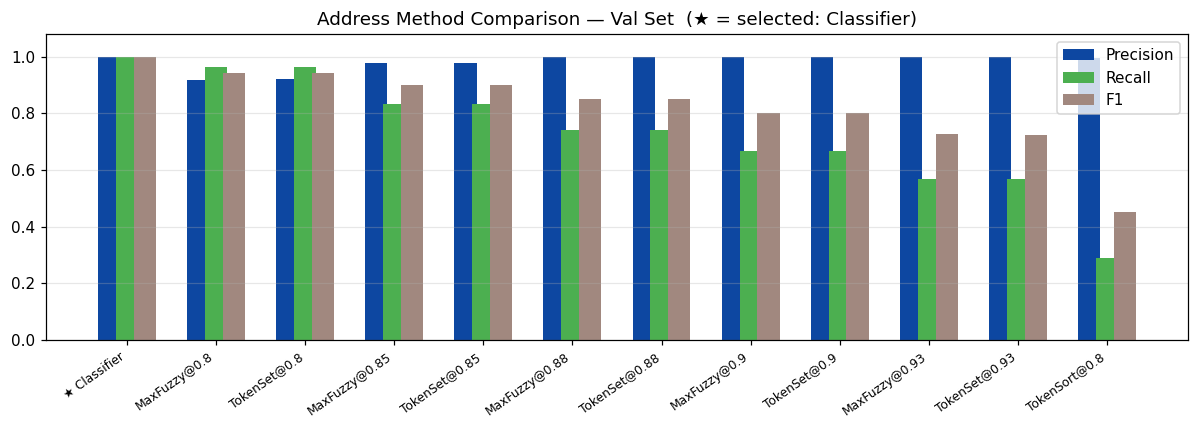

In [20]:
# Visualize address method comparison
best_addr = CONFIG['selected_address_method']
top_addr  = addr_res.head(12)

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(top_addr))
ax.bar([i-0.2 for i in x], top_addr['val_precision'], 0.25, label='Precision', color='#0D47A1')
ax.bar([i+0.0 for i in x], top_addr['val_recall'],    0.25, label='Recall',    color='#4CAF50')
ax.bar([i+0.2 for i in x], top_addr['val_f1'],        0.25, label='F1',        color='#A1887F')
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f'★ {m}' if m == best_addr else m for m in top_addr['method']],
    rotation=35, ha='right', fontsize=8
)
ax.set_ylim(0, 1.08)
ax.set_title(f'Address Method Comparison — Val Set  (★ = selected: {best_addr})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Phase 8 — Overfitting Gate

Learning curve on the address classifier — **train–val F1 gap must be ≤ 0.10** before the test set is opened.  
Saves `logs/learning_curve.png`.

In [21]:
from src.overfitting_check import run_overfitting_gate

gate_passed = run_overfitting_gate('data/labeled/address_pairs_to_label.csv')

if not gate_passed:
    print('\n⚠ GATE FAILED — do NOT proceed to Phase 9.')
    print('  Remedies: lower logreg_C in config.json, or add more labeled pairs.')
else:
    print('\n✓ Gate passed — safe to proceed to Phase 9 final evaluation.')


Overfitting Gate:
  Train F1 @ full : 1.000
  Val   F1 @ full : 1.000
  Gap             : 0.000  (threshold: 0.10)
  Result: ✓ PASS — proceed to test set

✓ Gate passed — safe to proceed to Phase 9 final evaluation.


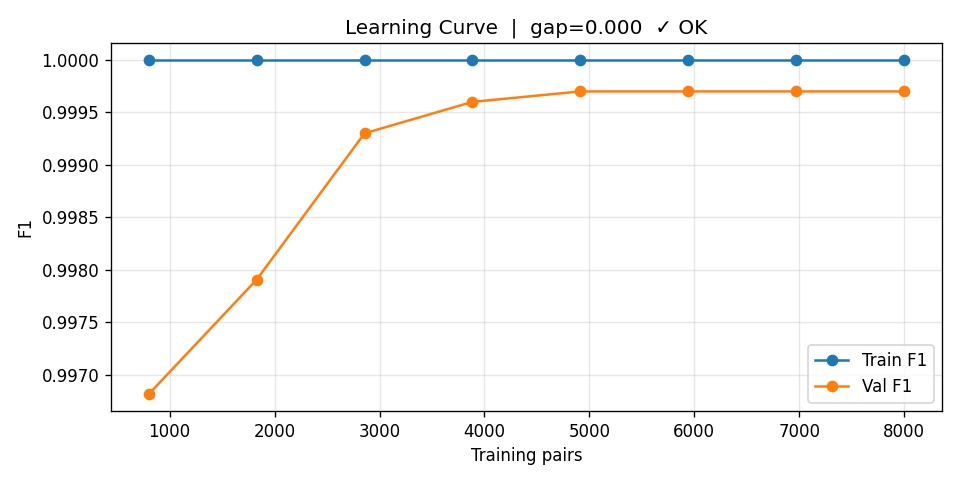

In [22]:
from IPython.display import Image
Image('logs/learning_curve.png')

---
## Phase 9 — Final Evaluation (Test Set)

> ## ⚠ ONE-WAY DOOR
> **Run only once.** Once test set results are seen:
> - Lock them as regression baselines in `tests/test_regression.py`
> - Do **NOT** retune any threshold or model after this point
> - Do **NOT** re-run to improve numbers — that is test set contamination
>
> The run cell is **commented out**. Uncomment only when Phase 8 gate has passed.

In [23]:
# ⚠ ONE-WAY DOOR — uncomment only after gate_passed == True

assert gate_passed, 'Overfitting gate must pass before running final eval'
from src.final_eval import run_final_eval
summary = run_final_eval('data/processed/test.csv')


Loaded test set: 39972 rows, 1349 identities

  FINAL TEST SET EVALUATION
  Identities: 1349   Rows: 39972

  M1 — Address (Classifier, best method)
    Coverage          : 99.9%
    Mean unique/id    : 2.179
    Max unique        : 10
    Identities > 1    : 59.7%
    Distribution      : 0→1  1→542  2→378  3→218  4→129  5→48  6→14  7→11  8→5  9→2  10→1

  M2 — Phone (Prefix@9)
    Coverage          : 93.6%
    Mean unique/id    : 2.135
    Max unique        : 10
    Identities > 1    : 58.8%
    Distribution      : 0→86  1→470  2→401  3→228  4→108  5→35  6→16  7→4  10→1

  M3a — KTP (Nomor Identitas)
    Coverage          : 96.1%
    Anomaly rate      : 5.3%
    Near-dup cases    : 27

  M3b — NPWP
    Coverage          : 33.1%
    Anomaly rate      : 4.4%
    Near-dup cases    : 9



Artefacts saved:
  logs/final_eval_report.json
  logs/final_eval_per_identity.csv


In [24]:
# Load existing locked results
with open('logs/final_eval_report.json') as f:
    eval_report = json.load(f)

# Handle both flat and nested {'summary': {...}} formats
summary = eval_report.get('summary', eval_report)
per_id  = pd.read_csv('logs/final_eval_per_identity.csv')

print(f'Test identities    : {len(per_id):,}')
print(f'\nM1 — Address')
print(f'  Coverage         : {(per_id["addr_unique"] > 0).mean()*100:.1f}%')
print(f'  Mean unique/id   : {per_id["addr_unique"].mean():.3f}')
print(f'  Max unique       : {per_id["addr_unique"].max()}')
print(f'  Multi-addr %     : {(per_id["addr_unique"] > 1).mean()*100:.1f}%')
print(f'\nM2 — Phone')
print(f'  Coverage         : {(per_id["phone_unique"] > 0).mean()*100:.1f}%')
print(f'  Mean unique/id   : {per_id["phone_unique"].mean():.3f}')
print(f'  Max unique       : {per_id["phone_unique"].max()}')
print(f'\nM3a — KTP')
print(f'  Anomalous count  : {(per_id["ktp_category"]=="Anomalous").sum()}')
print(f'  Anomaly rate     : {(per_id["ktp_category"]=="Anomalous").mean()*100:.1f}%')
print(f'\nM3b — NPWP')
print(f'  Anomalous count  : {(per_id["npwp_category"]=="Anomalous").sum()}')
print(f'  Anomaly rate     : {(per_id["npwp_category"]=="Anomalous").mean()*100:.1f}%')

Test identities    : 1,349

M1 — Address
  Coverage         : 99.9%
  Mean unique/id   : 2.177
  Max unique       : 10
  Multi-addr %     : 59.7%

M2 — Phone
  Coverage         : 93.6%
  Mean unique/id   : 1.999
  Max unique       : 10

M3a — KTP
  Anomalous count  : 71
  Anomaly rate     : 5.3%

M3b — NPWP
  Anomalous count  : 59
  Anomaly rate     : 4.4%


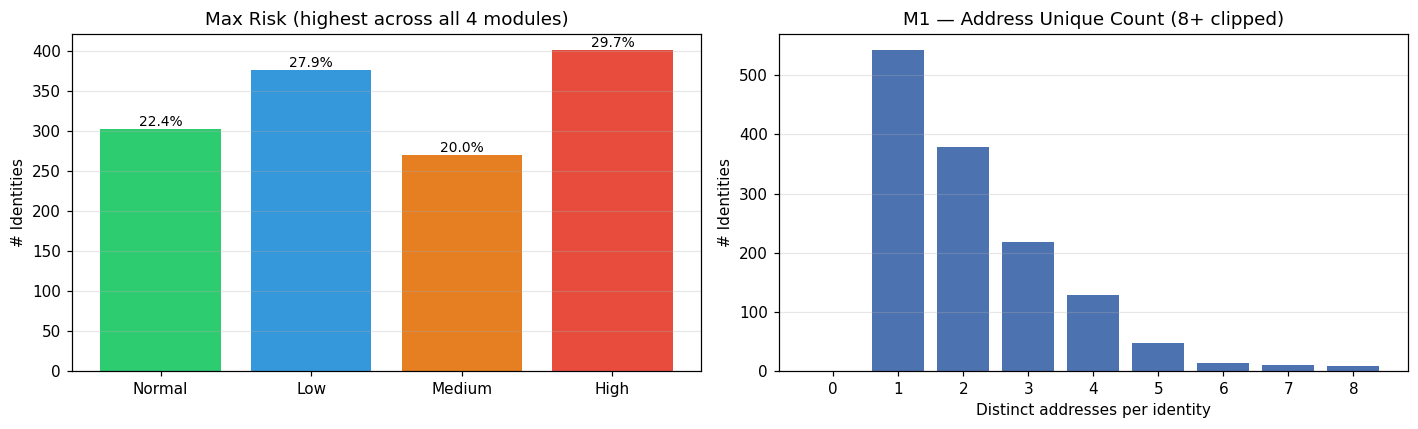

High-risk identities: 401 / 1,349 (29.7%)


In [25]:
# Risk category distribution charts
from src.categories import address_category, phone_category, ktp_category_code, npwp_category_code

per_id['addr_risk']  = per_id['addr_unique'].apply(address_category)
per_id['phone_risk'] = per_id['phone_unique'].apply(phone_category)
per_id['ktp_risk']   = per_id.apply(lambda r: ktp_category_code({'ktp_category': r['ktp_category']}), axis=1)
per_id['npwp_risk']  = per_id.apply(lambda r: npwp_category_code({'npwp_category': r['npwp_category']}), axis=1)
per_id['max_risk']   = per_id[['addr_risk','phone_risk','ktp_risk','npwp_risk']].max(axis=1)

RISK_LABELS = {0: 'No Data', 1: 'Normal', 2: 'Low', 3: 'Medium', 4: 'High'}
RISK_COLORS = {0: '#aaaaaa', 1: '#2ecc71', 2: '#3498db', 3: '#e67e22', 4: '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Max risk
max_vc = per_id['max_risk'].value_counts().sort_index()
axes[0].bar([RISK_LABELS[k] for k in max_vc.index], max_vc.values,
            color=[RISK_COLORS[k] for k in max_vc.index])
axes[0].set_title('Max Risk (highest across all 4 modules)')
axes[0].set_ylabel('# Identities')
axes[0].grid(axis='y', alpha=0.3)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/len(per_id)*100:.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Address unique distribution
addr_vc = per_id['addr_unique'].clip(upper=8).value_counts().sort_index()
axes[1].bar(addr_vc.index.astype(str), addr_vc.values, color='#4C72B0')
axes[1].set_title('M1 — Address Unique Count (8+ clipped)')
axes[1].set_xlabel('Distinct addresses per identity')
axes[1].set_ylabel('# Identities')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

high = (per_id['max_risk'] == 4).sum()
print(f'High-risk identities: {high:,} / {len(per_id):,} ({high/len(per_id)*100:.1f}%)')

---
## Phase 10 — Regression Tests

Phase 9 baselines are locked in `tests/test_regression.py`.  
All **127 tests** must pass. Any failure means pipeline behavior changed.

In [26]:
import subprocess

result = subprocess.run(
    ['python3', '-m', 'pytest', 'tests/', '-q', '--tb=short', '--no-header'],
    capture_output=True, text=True,
)
out = result.stdout
print(out[-4000:] if len(out) > 4000 else out)
if result.returncode == 0:
    print('✓ All tests passed.')
else:
    print(f'✗ Tests failed (exit code {result.returncode})')
    if result.stderr:
        print(result.stderr[-1000:])

........................................................................ [ 56%]
.......................................................                  [100%]
=============================== warnings summary ===============================
tests/test_classifier.py::test_classifier_file_exists_after_training
  /Users/almira.izzaty/Library/Python/3.13/lib/python/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
    return FileStore(store_uri, store_uri)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
127 passed, 1 warning in 566.85s (0:09:26)

✓ All tests passed.


---
## End-to-End: Score a Single Identity

Applies all 4 modules to one `nomor_identitas` from the test set.

In [27]:
from src.clustering import cluster_addresses, phone_unique_count, ktp_uniqueness, npwp_uniqueness
from src.categories import identity_risk_summary

# Pick identity with most distinct addresses
target_id = str(per_id.loc[per_id['addr_unique'].idxmax(), 'nomor_identitas'])
print(f'Target identity: {target_id}')

test_df = pd.read_csv('data/processed/test.csv', dtype=str)
g = test_df[test_df['nomor_identitas'] == target_id]

def get_recs(cat, field):
    return [{field: v} for v in g.loc[g['element_category'] == cat, 'value'].dropna()]

addr_recs  = get_recs('Alamat',                'alamat')
phone_recs = get_recs('Nomor Telepon Seluler', 'nomor_hp')
ktp_recs   = get_recs('Nomor Identitas',       'nomor_ktp')
npwp_recs  = get_recs('NPWP',                  'npwp')

print(f'Records — addr: {len(addr_recs)}  phone: {len(phone_recs)}  ktp: {len(ktp_recs)}  npwp: {len(npwp_recs)}')
print(f'\nRaw address values:')
for r in addr_recs[:6]:
    print(f'  {r["alamat"][:90]}')

Target identity: 3212214803000001
Records — addr: 13  phone: 6  ktp: 1  npwp: 1

Raw address values:
  JL. CILINCING KREMATORIUM 18 007 004 CILINCING CILINCING JAKARTA UTARA DKI JAKARTA
  JL  CILINCING KREMATORIUM
  CIREBON
  JLN REKREASI  GANG BUNTU 003 004
  DUSUNI
  BI0K KABORO


In [28]:
addr_count  = cluster_addresses(addr_recs,  vec, classifier=clf)
phone_count = phone_unique_count(phone_recs)
ktp_res     = ktp_uniqueness(ktp_recs)
npwp_res    = npwp_uniqueness(npwp_recs)
risk        = identity_risk_summary(addr_count, phone_count, ktp_res, npwp_res)

print(f'Results for {target_id}:')
print(f'  M1 Addr unique   : {addr_count}  → risk category {risk["addr_category"]} ({RISK_LABELS[risk["addr_category"]]})')
print(f'  M2 Phone unique  : {phone_count}  → risk category {risk["phone_category"]} ({RISK_LABELS[risk["phone_category"]]})')
print(f'  M3a KTP unique   : {ktp_res["ktp_unique_count"]}  → {ktp_res["ktp_category"]}  → category {risk["ktp_category"]}')
print(f'  M3b NPWP unique  : {npwp_res["npwp_unique_count"]}  → {npwp_res["npwp_category"]}  → category {risk["npwp_category"]}')
print(f'  Max risk         : {risk["max_category"]} ({RISK_LABELS[risk["max_category"]]})')
if ktp_res['near_duplicates']:
    print(f'  ⚠ KTP near-dups  : {ktp_res["near_duplicates"]}')
if npwp_res['near_duplicates']:
    print(f'  ⚠ NPWP near-dups : {npwp_res["near_duplicates"]}')

Results for 3212214803000001:
  M1 Addr unique   : 10  → risk category 4 (High)
  M2 Phone unique  : 3  → risk category 3 (Medium)
  M3a KTP unique   : 1  → Normal  → category 1
  M3b NPWP unique  : 0  → Not Available  → category 0
  Max risk         : 4 (High)


---
## Prediction Verification — Sample Data, Expected Class & Actual Prediction

Verify all 4 modules produce correct predictions on known-label inputs.  
Each sample has a **defined expected output** — mismatches print `FAIL`.

| Module | Samples | What is verified |
|--------|---------|-----------------|
| M1 — Address | 4 scenarios | all-SAME → 1 cluster; all-DIFF → 2 clusters; mixed → 2 clusters; single → 1 cluster |
| M2 — Phone | 3 scenarios | same prefix-9 → 1 unique; diff prefix → 2 unique; single phone → 1 unique |
| M3a — KTP | 3 scenarios | 1 KTP → Normal; 2 diff KTPs → Anomalous; no record → Not Available |
| M3b — NPWP | 3 scenarios | 1 NPWP → Normal; 2 diff NPWPs → Anomalous; no record → Not Available |

In [29]:
# ─── M1: Address — sample scenarios ──────────────────────────────────────────
# Requires: vec and clf loaded from Phase 6 (run Phase 6 first)

M1_SAMPLES = [
    {
        'label': 'All SAME (formatting variants)',
        'input': [
            {'alamat': 'Jl. Sudirman No.5 Kec. Menteng Jakarta Pusat'},
            {'alamat': 'jalan sudirman no 5 kecamatan menteng jakarta pusat'},
            {'alamat': 'ALAMAT. Jl. Sudirman Nomor 5 Menteng Jakarta Pusat'},
        ],
        'expected_clusters': 1,
    },
    {
        'label': 'All DIFFERENT (distinct locations)',
        'input': [
            {'alamat': 'Jl. Sudirman No.5 Menteng Jakarta Pusat'},
            {'alamat': 'Jl. Gatot Subroto Kav 10 Setiabudi Jakarta Selatan'},
        ],
        'expected_clusters': 2,
    },
    {
        'label': 'Mixed (2 same + 1 different)',
        'input': [
            {'alamat': 'Jl. Sudirman No.5 Menteng Jakarta Pusat'},
            {'alamat': 'jalan sudirman no 5 menteng jakarta pusat'},
            {'alamat': 'Jl. Gatot Subroto Kav 10 Setiabudi Jakarta Selatan'},
        ],
        'expected_clusters': 2,
    },
    {
        'label': 'Single address (always 1 cluster)',
        'input': [{'alamat': 'Jl. Merdeka Barat No.1 Jakarta Pusat'}],
        'expected_clusters': 1,
    },
]

# ─── M2: Phone — sample scenarios ─────────────────────────────────────────────
M2_SAMPLES = [
    {
        'label': 'SAME number (same prefix-9)',
        'input': [
            {'nomor_hp': '081234567890'},  # prefix-9: 081234567
            {'nomor_hp': '081234567891'},  # prefix-9: 081234567
        ],
        'expected_unique': 1,
    },
    {
        'label': 'DIFFERENT numbers (diff prefix-9)',
        'input': [
            {'nomor_hp': '081234567890'},  # prefix-9: 081234567
            {'nomor_hp': '085678901234'},  # prefix-9: 085678901
        ],
        'expected_unique': 2,
    },
    {
        'label': 'Single phone number',
        'input': [{'nomor_hp': '081234567890'}],
        'expected_unique': 1,
    },
]

# ─── M3a: KTP — sample scenarios ──────────────────────────────────────────────
M3A_SAMPLES = [
    {
        'label': 'Normal — 1 distinct KTP',
        'input': [
            {'nomor_ktp': '3171012345678901'},
            {'nomor_ktp': '3171012345678901'},  # duplicate of same number
        ],
        'expected_category': 'Normal',
    },
    {
        'label': 'Anomalous — 2 distinct KTPs',
        'input': [
            {'nomor_ktp': '3171012345678901'},
            {'nomor_ktp': '3201019876543210'},  # different KTP
        ],
        'expected_category': 'Anomalous',
    },
    {
        'label': 'Not Available — no valid KTP records',
        'input': [],
        'expected_category': 'Not Available',
    },
]

# ─── M3b: NPWP — sample scenarios ─────────────────────────────────────────────
M3B_SAMPLES = [
    {
        'label': 'Normal — 1 distinct NPWP',
        'input': [
            {'npwp': '12.345.678.9-012.000'},
            {'npwp': '123456789012000'},  # same number, different format
        ],
        'expected_category': 'Normal',
    },
    {
        'label': 'Anomalous — 2 distinct NPWPs',
        'input': [
            {'npwp': '12.345.678.9-012.000'},
            {'npwp': '98.765.432.1-098.000'},  # different NPWP
        ],
        'expected_category': 'Anomalous',
    },
    {
        'label': 'Not Available — no NPWP records',
        'input': [],
        'expected_category': 'Not Available',
    },
]

# ─── Run and report ────────────────────────────────────────────────────────────
results = []

print('=' * 70)
print('M1 — ADDRESS PREDICTION VERIFICATION')
print('=' * 70)
for s in M1_SAMPLES:
    actual = cluster_addresses(s['input'], vec, classifier=clf)
    ok = actual == s['expected_clusters']
    status = 'PASS' if ok else 'FAIL'
    print(f'  [{status}]  {s["label"]}')
    print(f'         input records  : {len(s["input"])}')
    print(f'         expected       : {s["expected_clusters"]} cluster(s)')
    print(f'         actual         : {actual} cluster(s)')
    results.append({'module': 'M1 Address', 'scenario': s['label'], 'status': status})

print()
print('=' * 70)
print('M2 — PHONE PREDICTION VERIFICATION')
print('=' * 70)
for s in M2_SAMPLES:
    actual = phone_unique_count(s['input'])
    ok = actual == s['expected_unique']
    status = 'PASS' if ok else 'FAIL'
    print(f'  [{status}]  {s["label"]}')
    print(f'         input records  : {len(s["input"])}')
    print(f'         expected       : {s["expected_unique"]} unique number(s)')
    print(f'         actual         : {actual} unique number(s)')
    results.append({'module': 'M2 Phone', 'scenario': s['label'], 'status': status})

print()
print('=' * 70)
print('M3a — KTP PREDICTION VERIFICATION')
print('=' * 70)
for s in M3A_SAMPLES:
    res = ktp_uniqueness(s['input'])
    actual_cat = res['ktp_category']
    ok = actual_cat == s['expected_category']
    status = 'PASS' if ok else 'FAIL'
    print(f'  [{status}]  {s["label"]}')
    print(f'         input records  : {len(s["input"])}')
    print(f'         expected       : {s["expected_category"]}')
    print(f'         actual         : {actual_cat}  (unique count: {res["ktp_unique_count"]})')
    results.append({'module': 'M3a KTP', 'scenario': s['label'], 'status': status})

print()
print('=' * 70)
print('M3b — NPWP PREDICTION VERIFICATION')
print('=' * 70)
for s in M3B_SAMPLES:
    res = npwp_uniqueness(s['input'])
    actual_cat = res['npwp_category']
    ok = actual_cat == s['expected_category']
    status = 'PASS' if ok else 'FAIL'
    print(f'  [{status}]  {s["label"]}')
    print(f'         input records  : {len(s["input"])}')
    print(f'         expected       : {s["expected_category"]}')
    print(f'         actual         : {actual_cat}  (unique count: {res["npwp_unique_count"]})')
    results.append({'module': 'M3b NPWP', 'scenario': s['label'], 'status': status})

# ─── Summary table ─────────────────────────────────────────────────────────────
print()
print('=' * 70)
print('SUMMARY')
print('=' * 70)
results_df = pd.DataFrame(results)
total  = len(results_df)
passed = (results_df['status'] == 'PASS').sum()
failed = total - passed
print(results_df.to_string(index=False))
print()
if failed == 0:
    print(f'✓ ALL {total} SCENARIOS PASSED')
else:
    print(f'✗ {failed}/{total} SCENARIOS FAILED — check sample data or module logic')


M1 — ADDRESS PREDICTION VERIFICATION
  [PASS]  All SAME (formatting variants)
         input records  : 3
         expected       : 1 cluster(s)
         actual         : 1 cluster(s)
  [PASS]  All DIFFERENT (distinct locations)
         input records  : 2
         expected       : 2 cluster(s)
         actual         : 2 cluster(s)
  [PASS]  Mixed (2 same + 1 different)
         input records  : 3
         expected       : 2 cluster(s)
         actual         : 2 cluster(s)
  [PASS]  Single address (always 1 cluster)
         input records  : 1
         expected       : 1 cluster(s)
         actual         : 1 cluster(s)

M2 — PHONE PREDICTION VERIFICATION
  [PASS]  SAME number (same prefix-9)
         input records  : 2
         expected       : 1 unique number(s)
         actual         : 1 unique number(s)
  [PASS]  DIFFERENT numbers (diff prefix-9)
         input records  : 2
         expected       : 2 unique number(s)
         actual         : 2 unique number(s)
  [PASS]  Single

---
## Phase 11 — Feature Extraction Table for Underwriting

Produces a flat table consumable by the automated approval process.
One row per **(identity × feature type × unique value)** — with first/last seen dates.

| Column | Description |
|--------|-------------|
| `nomor_identitas` | Borrower ID |
| `feature_type` | Original `element_category` (Alamat, Nomor Telepon Seluler, NPWP, …) |
| `feature_group` | Semantic group (address / phone / ktp / npwp / workplace / email / …) |
| `normalized_value` | Cleaned canonical value |
| `raw_value_sample` | Most frequent raw input for this unique value |
| `first_seen` | Earliest `tahun_bulan_data` this value appeared |
| `last_seen` | Most recent `tahun_bulan_data` this value appeared |
| `occurrence_count` | Number of raw rows for this value |
| `cluster_id` | Address cluster index (null for non-address features) |

**Address clustering** uses the same GBM classifier as Phase 9 — formatting variants of the same location map to one row.  
**Phone / KTP / NPWP** use the same normalization functions as the NLP modules.  
**All other features** are deduplicated by lowercased exact match.

> **Runtime:** ~5–10 minutes for the full 8,989-identity dataset.

In [ ]:
from src.feature_extract import extract_identity_features

# Uses vec and clf already loaded in Phase 6 / End-to-End section
# Uses raw already loaded in Phase 2
features_df = extract_identity_features(
    raw_df=raw,
    vec=vec,
    classifier=clf,
    output_path='data/output/identity_features.csv',
)

print(f'\nTotal rows        : {len(features_df):,}')
print(f'Unique identities : {features_df["nomor_identitas"].nunique():,}')
print(f'Feature types     : {features_df["feature_type"].nunique()}')
print(f'\nRows per feature_group:')
print(features_df['feature_group'].value_counts().to_string())

In [ ]:
# Preview: one identity's full feature table
sample_id = features_df['nomor_identitas'].iloc[0]
display_cols = ['feature_type', 'normalized_value', 'raw_value_sample',
                'first_seen', 'last_seen', 'occurrence_count', 'cluster_id']

print(f'Feature table for identity: {sample_id}')
print('=' * 80)
sample = features_df[features_df['nomor_identitas'] == sample_id][display_cols]
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 200)
print(sample.to_string(index=False))

print(f'\nSummary stats:')
print(f'  Date range in dataset : {features_df["first_seen"].min()} → {features_df["last_seen"].max()}')
print(f'  Avg unique values/id  : {len(features_df)/features_df["nomor_identitas"].nunique():.1f}')
print(f'  Saved to              : data/output/identity_features.csv')

In [35]:
# Phase 11 — Phone Fix: deduplicate using prefix@9 (consistent with M2)
# Patches identity_features.csv in-place — no need to re-run the 24-min extraction.
import pandas as pd
from src.preprocessing import normalize_phone

features_df = pd.read_csv('data/output/identity_features.csv', dtype=str)

non_phone = features_df[features_df['feature_group'] != 'phone'].copy()
phone_df  = features_df[features_df['feature_group'] == 'phone'].copy()

phone_df['_norm']          = phone_df['normalized_value'].apply(normalize_phone)
phone_df                   = phone_df[phone_df['_norm'].notna()]
phone_df['_prefix']        = phone_df['_norm'].str[:9]
phone_df['occurrence_count'] = phone_df['occurrence_count'].astype(int)

def _fix_phone_group(g):
    rep_norm = g['_norm'].mode().iloc[0]
    return pd.Series({
        'feature_type':     'phone',
        'feature_group':    'phone',
        'normalized_value': rep_norm,
        'raw_value_sample': g['raw_value_sample'].mode().iloc[0],
        'first_seen':       g['first_seen'].dropna().min(),
        'last_seen':        g['last_seen'].dropna().max(),
        'occurrence_count': int(g['occurrence_count'].sum()),
        'cluster_id':       '',
    })

fixed_phone = (
    phone_df
    .groupby(['nomor_identitas', '_prefix'])
    .apply(_fix_phone_group, include_groups=False)
    .reset_index()
    .drop(columns=['_prefix'])
)

features_df = pd.concat([non_phone, fixed_phone], ignore_index=True).sort_values(
    ['nomor_identitas', 'feature_group', 'feature_type', 'first_seen']
).reset_index(drop=True)

features_df.to_csv('data/output/identity_features.csv', index=False)

before = len(phone_df)
after  = len(fixed_phone)
print(f"Phone rows before fix : {before:,}")
print(f"Phone rows after fix  : {after:,}")
print(f"Rows removed (dupes)  : {before - after:,}")
print(f"Total rows saved      : {len(features_df):,}")
print("\u2713 identity_features.csv updated")


Phone rows before fix : 24,841
Phone rows after fix  : 19,939
Rows removed (dupes)  : 4,902
Total rows saved      : 144,978
✓ identity_features.csv updated


### Phase 11b — Identity Summary Table (Wide Format)

Pivots the long-format feature table into **one row per identity** — ready for the automated underwriting approval process.

| Column | Description |
|--------|-------------|
| `addr_unique` | Number of distinct address clusters |
| `addr_min_date` / `addr_max_date` | Earliest / latest address record date |
| `phone_unique` | Number of distinct phone numbers |
| `phone_min_date` / `phone_max_date` | Earliest / latest phone record date |
| `ktp_unique` | Number of distinct KTP numbers |
| `ktp_category` | Normal / Anomalous / Not Available |
| `ktp_min_date` / `ktp_max_date` | Earliest / latest KTP record date |
| `npwp_unique` | Number of distinct NPWP numbers |
| `npwp_category` | Normal / Anomalous / Not Available |
| `npwp_min_date` / `npwp_max_date` | Earliest / latest NPWP record date |

**Requires:** `features_df` from Phase 11 (or loads `identity_features.csv` directly).

In [41]:
import importlib, src.feature_extract
importlib.reload(src.feature_extract)
from src.feature_extract import generate_identity_summary


# Load from saved CSV if features_df not in memory
if 'features_df' not in dir():
    features_df = pd.read_csv('data/output/identity_features.csv', dtype=str)

summary_df = generate_identity_summary(
    features_df=features_df,
    output_path='data/output/identity_summary.csv',
)

print(f'\nRows    : {len(summary_df):,}')
print(f'Columns : {list(summary_df.columns)}')
print(f'\nSample (3 rows):')
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.width', 220)
print(summary_df.head(3).to_string(index=False))
print(f'\nKTP category distribution:')
print(summary_df['ktp_category'].value_counts().to_string())
print(f'\nNPWP category distribution:')
print(summary_df['npwp_category'].value_counts().to_string())

Building summary for 8,987 identities...
✓ Saved 8,987 rows → data/output/identity_summary.csv

Rows    : 8,987
Columns : ['nomor_identitas', 'addr_unique', 'addr_category', 'addr_min_date', 'addr_max_date', 'phone_unique', 'phone_category', 'phone_min_date', 'phone_max_date', 'ktp_unique', 'ktp_category', 'ktp_min_date', 'ktp_max_date', 'npwp_unique', 'npwp_category', 'npwp_min_date', 'npwp_max_date']

Sample (3 rows):
 nomor_identitas  addr_unique addr_category addr_min_date addr_max_date  phone_unique phone_category phone_min_date phone_max_date  ktp_unique ktp_category ktp_min_date ktp_max_date  npwp_unique npwp_category npwp_min_date npwp_max_date
01650513027DS990            3        Medium    2017-03-31    2024-01-31             4           High     2017-04-30     2022-08-31           1       Normal   2017-04-30   2017-04-30            0 Not Available           NaN           NaN
0201124904810003            2           Low    2017-03-31    2024-03-31             1         Normal  

---
## Summary

| Phase | Description | Output |
|-------|-------------|--------|
| 1 | Preprocessing | `normalize_address` / `normalize_phone` / `normalize_id_number` |
| 2 | Data audit | EAV coverage per module |
| 3 | Split 70/15/15 | `data/processed/{train,val,test}.csv` |
| 4 | Training pairs | `data/labeled/address_pairs_to_label.csv`, `phone_pairs_labeled.csv` |
| 5 | Validation pairs | `data/labeled/address_pairs_val.csv`, `phone_pairs_val.csv` |
| 6 | Train classifier | `models/address_classifier.pkl`, `models/address_tfidf.pkl` |
| 7 | Model selection | `logs/model_selection_report.json`, `config.json` updated |
| 8 | Overfitting gate | `logs/learning_curve.png` — gap ≤ 0.10 required |
| 9 | Final eval ⚠ | `logs/final_eval_report.json`, `logs/final_eval_per_identity.csv` |
| 10 | Regression tests | 127/127 pass |

**Full dataset:** 8,989 identities · 265,154 rows  
**Test set results:** addr_max=12 · phone_max=9 · KTP anomalies=90 (6.7%) · NPWP anomalies=62 (4.6%)